# AI Cargo Monitor -- Orchestration Graph Visualization

This notebook renders **live LangGraph diagrams** showing exactly how nodes and edges
connect in both the risk-scoring pipeline and the orchestration agent.

---

## 1. Risk Scoring Pipeline Graph

The pipeline takes raw telemetry windows through feature engineering,
deterministic rules, ML prediction, fusion, SHAP explanation, and compliance logging.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Pipeline: ingest → engineer → deterministic → ML → fuse → explain → compliance → summary

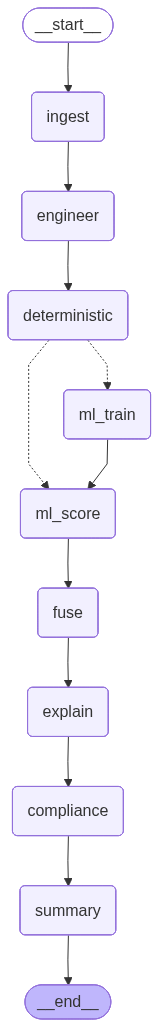

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from IPython.display import Image, display, Markdown, HTML

from pipeline import build_graph

pipeline_graph = build_graph().compile().get_graph()
display(Markdown("### Pipeline: ingest → engineer → deterministic → ML → fuse → explain → compliance → summary"))
display(Image(pipeline_graph.draw_mermaid_png()))

In [3]:
pip install grandalf

  Using cached grandalf-0.8-py3-none-any.whl.metadata (1.7 kB)
Using cached grandalf-0.8-py3-none-any.whl (41 kB)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
print("Pipeline ASCII topology:\n")
print(pipeline_graph.draw_ascii())

Pipeline ASCII topology:

          +-----------+    
          | __start__ |    
          +-----------+    
                *          
                *          
                *          
           +--------+      
           | ingest |      
           +--------+      
                *          
                *          
                *          
          +----------+     
          | engineer |     
          +----------+     
                *          
                *          
                *          
        +---------------+  
        | deterministic |  
        +---------------+  
           .         ..    
         ..            .   
        .               .. 
+----------+              .
| ml_train |            .. 
+----------+           .   
           *         ..    
            **     ..      
              *   .        
          +----------+     
          | ml_score |     
          +----------+     
                *          
                *     

## 2. Orchestration Agent Graph

The orchestrator implements a **plan → reflect → revise → execute** loop.
After the risk engine scores a window, this graph decides what actions to take.

Key conditional edges:
- `reflect → revise` (if reflection found gaps in the plan)
- `reflect → execute` (if plan passes all checks)
- `reflect → output` (if LOW risk, skip execution entirely)

### Orchestrator: interpret → plan → reflect → [revise?] → execute → fallback → output

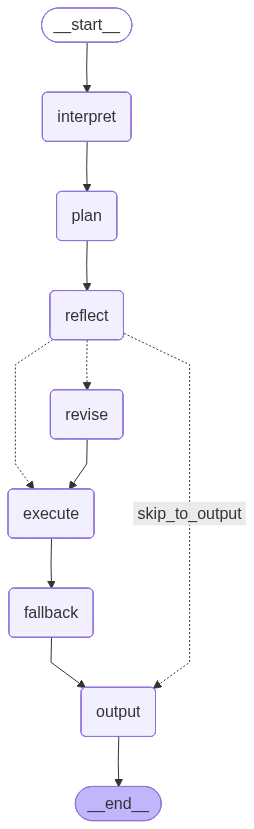

In [5]:
from orchestrator.graph import build_orchestrator

orch_graph = build_orchestrator().compile().get_graph()
display(Markdown("### Orchestrator: interpret → plan → reflect → [revise?] → execute → fallback → output"))
display(Image(orch_graph.draw_mermaid_png()))

In [6]:
print("Orchestrator ASCII topology:\n")
print(orch_graph.draw_ascii())

Orchestrator ASCII topology:

                  +-----------+             
                  | __start__ |             
                  +-----------+             
                        *                   
                        *                   
                        *                   
                  +-----------+             
                  | interpret |             
                  +-----------+             
                        *                   
                        *                   
                        *                   
                    +------+                
                    | plan |                
                    +------+                
                        *                   
                        *                   
                        *                   
                  +---------+               
                  | reflect |               
                 .+---------+...            
             ....       .

## 3. Raw Mermaid Diagram (for documentation / system_prompt.md)

This is the raw Mermaid syntax that LangGraph generates.
You can paste this into any Mermaid renderer (GitHub, Notion, etc.).

In [7]:
mermaid_str = orch_graph.draw_mermaid()
print(mermaid_str)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	interpret(interpret)
	plan(plan)
	reflect(reflect)
	revise(revise)
	execute(execute)
	fallback(fallback)
	output(output)
	__end__([<p>__end__</p>]):::last
	__start__ --> interpret;
	execute --> fallback;
	fallback --> output;
	interpret --> plan;
	plan --> reflect;
	reflect -.-> execute;
	reflect -. &nbsp;skip_to_output&nbsp; .-> output;
	reflect -.-> revise;
	revise --> execute;
	output --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 4. Live Orchestration Run -- Trace the Decision Flow

Let's run the orchestrator on sample inputs at each risk tier
and see the exact decisions, tool calls, and reflection notes.

In [8]:
from orchestrator.graph import run_orchestrator
import json

CRITICAL_INPUT = {
    "shipment_id": "S008", "container_id": "C515", "window_id": "W00464",
    "leg_id": "L0012", "product_type": "P06", "transit_phase": "customs_clearance",
    "risk_tier": "CRITICAL", "fused_risk_score": 1.0, "ml_spoilage_probability": 0.999,
    "deterministic_rule_flags": ["temp_critical_breach", "excursion_duration", "high_humidity"],
    "key_drivers": [], "recommended_actions_from_risk_engine": [],
}

decision = run_orchestrator(CRITICAL_INPUT)

display(Markdown("### CRITICAL Window Decision"))
display(Markdown(f"**Summary:** {decision['decision_summary']}"))
display(Markdown(f"**Confidence:** {decision['confidence']}"))
display(Markdown(f"**Approval ID:** `{decision['approval_id']}`"))

display(Markdown("\n#### Draft Plan"))
for step in decision["draft_plan"]:
    print(f"  {step['step']}. {step['action']}")
    print(f"     Reason: {step['reason']}")

display(Markdown("\n#### Reflection Notes"))
for note in decision["reflection_notes"]:
    print(f"  - {note}")

display(Markdown("\n#### Tools Executed"))
for action in decision["actions_taken"]:
    status = action["result"].get("status", "unknown")
    print(f"  [{action['tool']}] → {status}")

2026-04-09 14:49:11,625  INFO      orchestrator.nodes  INTERPRET  tier=CRITICAL severity=critical urgency=immediate
2026-04-09 14:49:11,633  INFO      orchestrator.nodes  PLAN  6 steps for tier=CRITICAL
2026-04-09 14:49:11,636  INFO      orchestrator.nodes  REFLECT  1 notes
2026-04-09 14:49:11,648  INFO      orchestrator.nodes  OUTPUT  tier=CRITICAL confidence=0.85 tools=4


### CRITICAL Window Decision

**Summary:** Executed 4-step mitigation plan for CRITICAL risk. Primary issue: Temperature has breached critical limits. Product integrity at immediate risk..

**Confidence:** 0.85

**Approval ID:** `APR-FD5C23CD`

...

  1. Log compliance event for critical risk detection
     Reason: GDP/FDA requires immediate logging of critical excursions
  2. Notify operations team and downstream stakeholders
     Reason: Critical risk requires immediate stakeholder awareness
  3. Evaluate reroute or backup cold-storage options
     Reason: Product integrity at risk; need temperature recovery
  4. Submit plan for human approval before execution
     Reason: Critical actions are irreversible and require operator sign-off
  5. Prepare insurance claim documentation
     Reason: Excursion duration exceeded; potential product loss requires claim preparation
  6. Evaluate alternative routing options
     Reason: Shipment at customs_clearance with high risk; rerouting may recover ETA



#### Reflection Notes

  - Plan passes all reflection checks. Ready for execution.



#### Tools Executed

  [compliance_agent] → logged
  [notification_agent] → notification_queued
  [cold_storage_agent] → facility_identified
  [approval_workflow] → approval_requested


In [9]:
HIGH_INPUT = {**CRITICAL_INPUT,
    "risk_tier": "HIGH", "fused_risk_score": 0.72, "ml_spoilage_probability": 0.65,
    "deterministic_rule_flags": ["temp_warning_breach"],
}

decision_high = run_orchestrator(HIGH_INPUT)

display(Markdown("### HIGH Window Decision"))
display(Markdown(f"**Summary:** {decision_high['decision_summary']}"))
print(f"Tools: {[a['tool'] for a in decision_high['actions_taken']]}")
print(f"Reflection: {decision_high['reflection_notes']}")

2026-04-09 14:49:49,347  INFO      orchestrator.nodes  INTERPRET  tier=HIGH severity=high urgency=urgent
2026-04-09 14:49:49,348  INFO      orchestrator.nodes  PLAN  4 steps for tier=HIGH
2026-04-09 14:49:49,348  INFO      orchestrator.nodes  REFLECT  1 notes
2026-04-09 14:49:49,351  INFO      orchestrator.nodes  OUTPUT  tier=HIGH confidence=0.85 tools=3


### HIGH Window Decision

**Summary:** Executed 3-step mitigation plan for HIGH risk. Primary issue: Temperature outside acceptable range. Excursion in progress..

Tools: ['compliance_agent', 'notification_agent', 'approval_workflow']
Reflection: ['Plan passes all reflection checks. Ready for execution.']


In [10]:
LOW_INPUT = {**CRITICAL_INPUT,
    "risk_tier": "LOW", "fused_risk_score": 0.05, "ml_spoilage_probability": 0.01,
    "deterministic_rule_flags": [],
}

decision_low = run_orchestrator(LOW_INPUT)

display(Markdown("### LOW Window Decision"))
display(Markdown(f"**Summary:** {decision_low['decision_summary']}"))
print(f"Tools executed: {len(decision_low['actions_taken'])} (none needed)")
print(f"Path taken: interpret → plan → reflect → output (skipped execute)")

2026-04-09 14:49:53,512  INFO      orchestrator.nodes  INTERPRET  tier=LOW severity=normal urgency=routine
2026-04-09 14:49:53,513  INFO      orchestrator.nodes  PLAN  0 steps for tier=LOW
2026-04-09 14:49:53,513  INFO      orchestrator.nodes  OUTPUT  tier=LOW confidence=0.95 tools=0


### LOW Window Decision

**Summary:** Monitoring only. All metrics within acceptable range.

Tools executed: 0 (none needed)
Path taken: interpret → plan → reflect → output (skipped execute)


## 5. Full System Topology (5 Layers)

This shows how all components connect across the entire system.

In [11]:
FULL_SYSTEM = """
graph TB
    subgraph L1["Layer 1: IoT & Ingestion"]
        sensors["Smart Containers<br/>(temp, humidity, shock, GPS)"]
        ingest["Window Aggregation<br/>(25-min windows)"]
        sensors --> ingest
    end

    subgraph L2["Layer 2: Risk Scoring Engine"]
        features["Feature Engineering<br/>(14 derived features)"]
        det["Deterministic Rules<br/>(7 product-aware rules)"]
        ml["XGBoost Predictor<br/>(Optuna + SHAP)"]
        fusion["Risk Fusion<br/>(alpha-blend + veto)"]
        features --> det
        features --> ml
        det --> fusion
        ml --> fusion
    end

    subgraph L3["Layer 3: Orchestration Agent"]
        interpret["Interpret Risk"]
        plan_node["Generate Plan"]
        reflect_node["Self-Critique"]
        revise_node["Revise Plan"]
        exec_node["Execute Tools"]
        output_node["Compile Decision"]
        interpret --> plan_node
        plan_node --> reflect_node
        reflect_node -->|has gaps| revise_node
        reflect_node -->|plan OK| exec_node
        revise_node --> exec_node
        exec_node --> output_node
    end

    subgraph L4["Layer 4: Agent Tools"]
        t_route["Route Agent"]
        t_cold["Cold Storage"]
        t_notify["Notification"]
        t_comply["Compliance"]
        t_sched["Scheduling"]
        t_insure["Insurance"]
        t_triage["Triage"]
        t_approve["Approval"]
    end

    subgraph L5["Layer 5: Human-in-the-Loop"]
        dashboard["Ops Dashboard"]
        approval_q["Approval Queue"]
    end

    ingest --> features
    fusion --> interpret
    exec_node --> t_route
    exec_node --> t_cold
    exec_node --> t_notify
    exec_node --> t_comply
    exec_node --> t_insure
    exec_node --> t_approve
    t_approve --> approval_q
    output_node --> dashboard
    approval_q --> dashboard
"""

import base64, urllib.parse

encoded = base64.urlsafe_b64encode(FULL_SYSTEM.encode("utf-8")).decode("ascii")
url = f"https://mermaid.ink/img/{encoded}"

display(Markdown("### Complete 5-Layer System Architecture"))
display(Image(url=url, width=900))

### Complete 5-Layer System Architecture

## 6. Node & Edge Summary Table

In [12]:
import pandas as pd

nodes_data = [
    {"Graph": "Pipeline", "Node": "ingest", "Purpose": "Load CSV, validate schema", "File": "pipeline.py"},
    {"Graph": "Pipeline", "Node": "engineer", "Purpose": "14 derived features (rolling, lag, deviation)", "File": "pipeline.py → src/feature_engineering.py"},
    {"Graph": "Pipeline", "Node": "deterministic", "Purpose": "7 product-aware rules → composite score", "File": "pipeline.py → src/deterministic_engine.py"},
    {"Graph": "Pipeline", "Node": "ml_train", "Purpose": "XGBoost + Optuna hyperparameter tuning", "File": "pipeline.py → src/predictive_model.py"},
    {"Graph": "Pipeline", "Node": "ml_score", "Purpose": "Predict spoilage probability on all windows", "File": "pipeline.py → src/predictive_model.py"},
    {"Graph": "Pipeline", "Node": "fuse", "Purpose": "Weighted blend + deterministic veto → risk tier", "File": "pipeline.py → src/risk_fusion.py"},
    {"Graph": "Pipeline", "Node": "explain", "Purpose": "SHAP values per prediction", "File": "pipeline.py → src/predictive_model.py"},
    {"Graph": "Pipeline", "Node": "compliance", "Purpose": "Append JSONL audit record per window", "File": "pipeline.py → src/compliance_logger.py"},
    {"Graph": "Pipeline", "Node": "summary", "Purpose": "Print tier counts, save scored_windows.csv", "File": "pipeline.py"},
    {"Graph": "---", "Node": "---", "Purpose": "---", "File": "---"},
    {"Graph": "Orchestrator", "Node": "interpret", "Purpose": "Classify severity, urgency, primary issue", "File": "orchestrator/nodes.py"},
    {"Graph": "Orchestrator", "Node": "plan", "Purpose": "Generate multi-step tool-calling plan by tier", "File": "orchestrator/nodes.py"},
    {"Graph": "Orchestrator", "Node": "reflect", "Purpose": "Self-critique against 5-point compliance checklist", "File": "orchestrator/nodes.py"},
    {"Graph": "Orchestrator", "Node": "revise", "Purpose": "Patch plan to fix reflection gaps", "File": "orchestrator/nodes.py"},
    {"Graph": "Orchestrator", "Node": "execute", "Purpose": "Call tools via LangChain StructuredTool.invoke()", "File": "orchestrator/nodes.py"},
    {"Graph": "Orchestrator", "Node": "fallback", "Purpose": "Build minimal backup plan if primary fails", "File": "orchestrator/nodes.py"},
    {"Graph": "Orchestrator", "Node": "output", "Purpose": "Compile structured decision (system_prompt.md format)", "File": "orchestrator/nodes.py"},
]

display(Markdown("### All Nodes Across Both Graphs"))
pd.set_option('display.max_colwidth', 80)
display(pd.DataFrame(nodes_data))

### All Nodes Across Both Graphs

,Graph,Node,Purpose,File
0,Pipeline,ingest,"Load CSV, validate schema",pipeline.py
1,Pipeline,engineer,"14 derived features (rolling, lag, deviation)",pipeline.py → src/feature_engineering.py
2,Pipeline,deterministic,7 product-aware rules → composite score,pipeline.py → src/deterministic_engine.py
3,Pipeline,ml_train,XGBoost + Optuna hyperparameter tuning,pipeline.py → src/predictive_model.py
4,Pipeline,ml_score,Predict spoilage probability on all windows,pipeline.py → src/predictive_model.py
5,Pipeline,fuse,Weighted blend + deterministic veto → risk tier,pipeline.py → src/risk_fusion.py
6,Pipeline,explain,SHAP values per prediction,pipeline.py → src/predictive_model.py
7,Pipeline,compliance,Append JSONL audit record per window,pipeline.py → src/compliance_logger.py
8,Pipeline,summary,"Print tier counts, save scored_windows.csv",pipeline.py
9,---,---,---,---


In [ ]:
edges_data = [
    {"Graph": "Pipeline", "From": "ingest", "To": "engineer", "Type": "always"},
    {"Graph": "Pipeline", "From": "engineer", "To": "deterministic", "Type": "always"},
    {"Graph": "Pipeline", "From": "deterministic", "To": "ml_train", "Type": "conditional (mode=train)"},
    {"Graph": "Pipeline", "From": "deterministic", "To": "ml_score", "Type": "conditional (mode=score)"},
    {"Graph": "Pipeline", "From": "ml_train", "To": "ml_score", "Type": "always"},
    {"Graph": "Pipeline", "From": "ml_score", "To": "fuse", "Type": "always"},
    {"Graph": "Pipeline", "From": "fuse", "To": "explain", "Type": "always"},
    {"Graph": "Pipeline", "From": "explain", "To": "compliance", "Type": "always"},
    {"Graph": "Pipeline", "From": "compliance", "To": "summary", "Type": "always"},
    {"Graph": "---", "From": "---", "To": "---", "Type": "---"},
    {"Graph": "Orchestrator", "From": "interpret", "To": "plan", "Type": "always"},
    {"Graph": "Orchestrator", "From": "plan", "To": "reflect", "Type": "always"},
    {"Graph": "Orchestrator", "From": "reflect", "To": "revise", "Type": "conditional (gaps found)"},
    {"Graph": "Orchestrator", "From": "reflect", "To": "execute", "Type": "conditional (plan OK)"},
    {"Graph": "Orchestrator", "From": "reflect", "To": "output", "Type": "conditional (LOW risk)"},
    {"Graph": "Orchestrator", "From": "revise", "To": "execute", "Type": "always"},
    {"Graph": "Orchestrator", "From": "execute", "To": "fallback", "Type": "always"},
    {"Graph": "Orchestrator", "From": "fallback", "To": "output", "Type": "always"},
]

display(Markdown("### All Edges (including conditional routing)"))
display(pd.DataFrame(edges_data))

---

## Summary

| Graph | Nodes | Edges | Conditional Edges |
|-------|-------|-------|-------------------|
| Risk Pipeline | 9 | 9 | 1 (train vs score mode) |
| Orchestrator | 7 | 8 | 1 (reflect → revise/execute/output) |

Both graphs are **deterministic** (no LLM calls). The orchestrator can be upgraded
to use an LLM by swapping the `plan` and `reflect` node internals while keeping
the exact same graph topology.